In [1]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.family'] = 'Arial'
import seaborn as sns
from scipy import stats
import cartopy.mpl.ticker as cticker
from scipy.ndimage import gaussian_filter
# from jupyterthemes import jtplot
# jtplot.style()


In [2]:
infile = xr.open_dataset('E:/google/IBTrACS.WP.v04r01.nc')

# 总路径

## 1982-2023的路径

## p1

In [3]:
def draw_bezier_arrow(ax, start, control, end, color='red', linewidth=2, arrowstyle='-|>', transform=None):
    # 使用贝塞尔曲线控制点绘制平滑曲线
    verts = [start, control, end]  # 起点，控制点，终点
    codes = [Path.MOVETO, Path.CURVE3, Path.CURVE3]  # 贝塞尔曲线的控制
    path = Path(verts, codes)
    patch = FancyArrowPatch(path=path, color=color, lw=linewidth, arrowstyle=arrowstyle, mutation_scale=20, transform=transform)
    ax.add_patch(patch)

In [4]:
#去掉标注0
def custom_label_format(val):
    if val == 0:
        return ''  # Do not show label for level 0
    else:
        return f'{val:g}'  # Show other labels normally

11.0


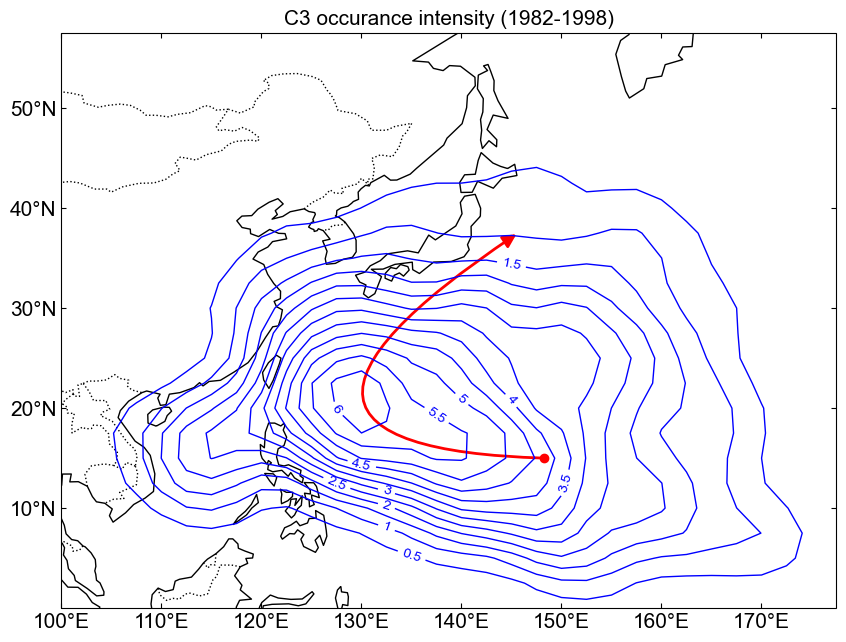

In [5]:
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
years = np.arange(1982, 1999)
typhoon_numbers = {}

for year in years:
    filtered_data = df[df['year'] == year]['Typhoon ID']
    typhoon_numbers[year] = filtered_data.values.flatten()
            
all_typhoon_ids = [id_num for ids in typhoon_numbers.values() for id_num in ids]
indall = np.array(all_typhoon_ids)


lons = infile['usa_lon'][indall].values
lats = infile['usa_lat'][indall].values
# 1. 生成2.5度间隔的经纬度格点
lon_bins = np.arange(100, 180 + 2.5, 2.5)  # 经度范围从100°E到180°E
lat_bins = np.arange(0, 60 + 2.5, 2.5)     # 纬度范围从0°N到60°N

# 3. 创建一个二维数组，用于存储每个网格的台风路径点出现次数
frequency_grid = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# 4. 遍历每个台风路径，处理有效路径点
for i in range(lons.shape[0]):  # 遍历每个台风
    for j in range(lons.shape[1]):  # 遍历每个台风的路径点
        lon = lons[i, j]
        lat = lats[i, j]
        
        # 跳过无效路径点 (NaN)
        if np.isnan(lon) or np.isnan(lat):
            continue
        
        # 将有效路径点映射到最近的网格
        lon_idx = np.digitize(lon, lon_bins) - 1  # 经度对应的网格索引
        lat_idx = np.digitize(lat, lat_bins) - 1  # 纬度对应的网格索引
        
        # 统计每个网格中的路径点次数
        if 0 <= lon_idx < frequency_grid.shape[1] and 0 <= lat_idx < frequency_grid.shape[0]:
            frequency_grid[lat_idx, lon_idx] += 1



p1=frequency_grid/17

frequency_grid_smooth = gaussian_filter(p1, sigma=1)
print(np.max(p1))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from scipy.ndimage import gaussian_filter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.path import Path


# 绘制平滑后的等值线图
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True, direction='in')
ax.set_xticks(np.arange(100, 181, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(10, 61, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(100, 181, 10), fontsize='15')
ax.set_yticklabels(np.arange(10, 61, 10), fontsize='15')
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')

# 绘制等值线图
contour = ax.contour(lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth, 
                     transform=ccrs.PlateCarree(), colors='b', linewidths=1, 
                     levels=np.arange(-4.5, 11, 0.5))

# 移除level == 0的等值线
for i, collection in enumerate(contour.collections):
    if contour.levels[i] == 0:
        collection.remove()

# 使用高斯滤波后的等值线
ax.clabel(contour, inline=True, fmt=custom_label_format)


#箭头线
start_point = (148.3, 15)  # 起点
end_point = (145.5, 37.4)  # 终点
control_point = (113.5, 16)  # 控制点，使曲线弯曲
ax.scatter(148.3, 15,color='r', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='red', transform=ccrs.PlateCarree())
# 设置标题
ax.set_title('C3 occurance intensity (1982-1998)', fontsize=15)

plt.show()
frequency_grid_smooth1=frequency_grid_smooth

##  p2

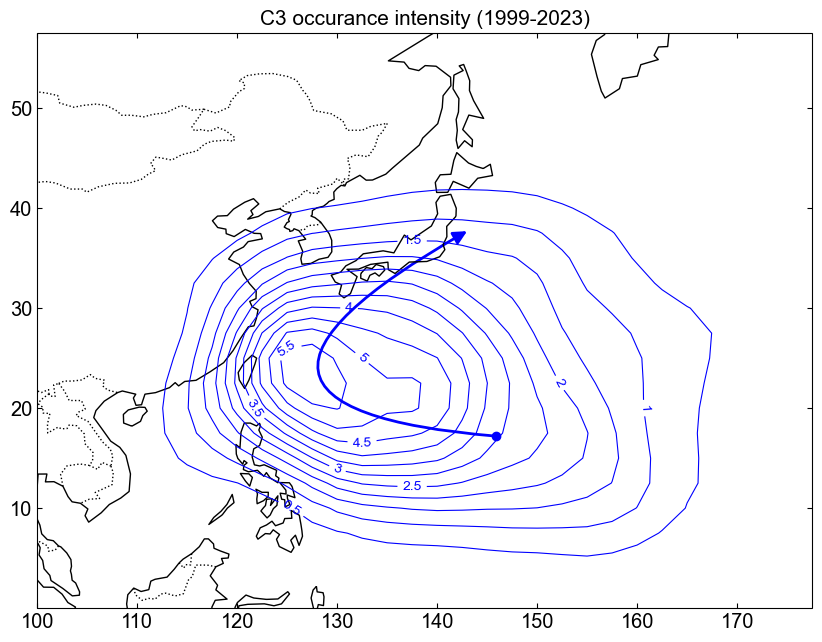

In [6]:
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
years = np.arange(1999, 2024)
typhoon_numbers = {}

for year in years:
    filtered_data = df[df['year'] == year]['Typhoon ID']
    typhoon_numbers[year] = filtered_data.values.flatten()
            
all_typhoon_ids = [id_num for ids in typhoon_numbers.values() for id_num in ids]
indall = np.array(all_typhoon_ids)


lons = infile['usa_lon'][indall].values
lats = infile['usa_lat'][indall].values
# 1. 生成2.5度间隔的经纬度格点
lon_bins = np.arange(100, 180 + 2.5, 2.5)  # 经度范围从100°E到180°E
lat_bins = np.arange(0, 60 + 2.5, 2.5)     # 纬度范围从0°N到60°N

# 3. 创建一个二维数组，用于存储每个网格的台风路径点出现次数
frequency_grid = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# 4. 遍历每个台风路径，处理有效路径点
for i in range(lons.shape[0]):  # 遍历每个台风
    for j in range(lons.shape[1]):  # 遍历每个台风的路径点
        lon = lons[i, j]
        lat = lats[i, j]
        
        # 跳过无效路径点 (NaN)
        if np.isnan(lon) or np.isnan(lat):
            continue
        
        # 将有效路径点映射到最近的网格
        lon_idx = np.digitize(lon, lon_bins) - 1  # 经度对应的网格索引
        lat_idx = np.digitize(lat, lat_bins) - 1  # 纬度对应的网格索引
        
        # 统计每个网格中的路径点次数
        if 0 <= lon_idx < frequency_grid.shape[1] and 0 <= lat_idx < frequency_grid.shape[0]:
            frequency_grid[lat_idx, lon_idx] += 1

p2=frequency_grid/25


# 3. 绘制等值线图
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(100, 181, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(10, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(100, 181, 10),fontsize = 'x-large') # 设置刻度标签
ax.set_yticklabels(np.arange(10, 61, 10),fontsize = 'x-large') # 设置刻度标签
# ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
# ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# 添加海岸线和国家边界
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')


# 使用高斯滤波对数据进行平滑处理
frequency_grid_smooth = gaussian_filter(p2, sigma=1.2)
# 绘制平滑后的等值线图
contour = ax.contour(lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth, 
                     transform=ccrs.PlateCarree(), colors='b', linewidths=0.8, 
                     levels=np.arange(0, 10, 0.5))


# 遍历等值线，移除level == 0的线
for i, collection in enumerate(contour.collections):
    if contour.levels[i] == 0:
        collection.remove()
        
# ax.clabel(contour, inline=True)        
        
# Use a custom formatter to avoid labeling the contour at level 0
def custom_label_format(val):
    if val == 0:
        return ''  # Do not show label for level 0
    else:
        return f'{val:g}'  # Show other labels normally

# Apply the custom formatter in ax.clabel
ax.clabel(contour, inline=True, fmt=custom_label_format)

        
ax.set_title('C3 occurance intensity (1999-2023)', fontsize=15)

# ax.scatter(145.9,17.2, color ='g', marker='s', s=100, transform=ccrs.Geodetic())
# ax.scatter(143,37.7, color ='g', marker='s', s=100, transform=ccrs.Geodetic())


#箭头线
start_point = (145.9,17.2)  # 起点
end_point = (143,37.7)  # 终点
control_point = (111.9, 20)  # 控制点，使曲线弯曲
ax.scatter(145.9,17.2,color='b', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='b', transform=ccrs.PlateCarree())



plt.show()
frequency_grid_smooth2=frequency_grid_smooth

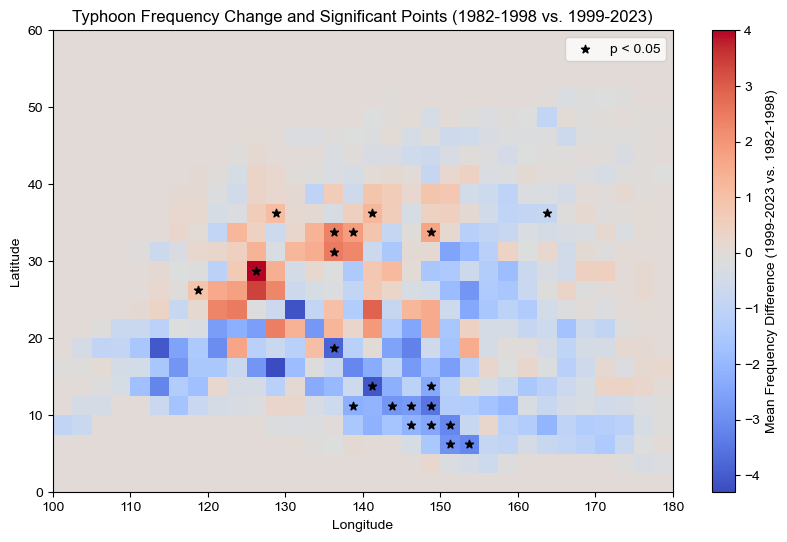

In [7]:
import numpy as np
from scipy.stats import ttest_ind

# 假设 `years` 是从 1982 到 2023 的年份
years = np.arange(1982, 2024)

# 初始化一个三维数组，用于存储每一年的台风生成频率
all_years_frequency_grid = np.zeros((len(years), len(lat_bins) - 1, len(lon_bins) - 1))

# 1. 计算每一年每个格点的台风生成频率
for year_idx, year in enumerate(years):
    # 筛选对应年份的数据
    filtered_data = df[df['year'] == year]['Typhoon ID']
    indall = filtered_data.values.flatten()
    
    lons = infile['usa_lon'][indall].values
    lats = infile['usa_lat'][indall].values
    
    # 创建一个二维数组用于存储该年份的路径点次数
    frequency_grid = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))
    
    # 遍历每个台风的路径点
    for i in range(lons.shape[0]):  # 遍历每个台风
        for j in range(lons.shape[1]):  # 遍历每个台风的路径点
            lon = lons[i, j]
            lat = lats[i, j]
            
            # 跳过无效路径点 (NaN)
            if np.isnan(lon) or np.isnan(lat):
                continue
            
            # 将有效路径点映射到最近的网格
            lon_idx = np.digitize(lon, lon_bins) - 1
            lat_idx = np.digitize(lat, lat_bins) - 1
            
            # 统计每个网格中的路径点次数
            if 0 <= lon_idx < frequency_grid.shape[1] and 0 <= lat_idx < frequency_grid.shape[0]:
                frequency_grid[lat_idx, lon_idx] += 1
    
    # 将每年的台风生成频率存入 `all_years_frequency_grid` 的对应年份索引
    all_years_frequency_grid[year_idx] = frequency_grid

# 2. 将1982-1998年和1999-2023年的频率数据分开
years_1 = np.arange(1982, 1999)  # 1982-1998
years_2 = np.arange(1999, 2024)  # 1999-2023


# 假设 `lat_bins` 和 `lon_bins` 已经定义
lon_bins = np.arange(100, 180 + 2.5, 2.5)  # 经度范围从100°E到180°E
lat_bins = np.arange(0, 60 + 2.5, 2.5)     # 纬度范围从0°N到60°N

# 分开两个时期的频率数据
freq_grid_1 = all_years_frequency_grid[:len(years_1)]
freq_grid_2 = all_years_frequency_grid[len(years_1):]

# 初始化一个二维数组来存储p值和t统计量
p_values = np.ones((len(lat_bins) - 1, len(lon_bins) - 1))
t_stats = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# 对每个格点执行t检验
for i in range(len(lat_bins) - 1):
    for j in range(len(lon_bins) - 1):
        # 获取两个时期在当前格点的频率值
        data_1 = freq_grid_1[:, i, j]
        data_2 = freq_grid_2[:, i, j]
        
        # 检查是否有非零的数据点
        if np.sum(data_1) > 0 and np.sum(data_2) > 0:
            # 执行t检验
            t_stat, p_val = ttest_ind(data_1, data_2, equal_var=False)  # 采用不假设方差相等的检验
            
            # 存储t统计量和p值
            t_stats[i, j] = t_stat
            p_values[i, j] = p_val

# 3. 绘制结果，显著性差异点使用星号标记
plt.figure(figsize=(10, 6))
plt.pcolormesh(lon_bins, lat_bins, np.mean(freq_grid_2, axis=0) - np.mean(freq_grid_1, axis=0), cmap='coolwarm')
plt.colorbar(label="Mean Frequency Difference (1999-2023 vs. 1982-1998)")
plt.title("Typhoon Frequency Change and Significant Points (1982-1998 vs. 1999-2023)")

# 设置显著性水平（例如 0.05）
significant_level = 0.05

# 标记显著差异的点
sig_x, sig_y = np.where(p_values < significant_level)

# 计算格点的中心坐标
lon_centers1 = (lon_bins[:-1] + lon_bins[1:]) / 2
lat_centers1 = (lat_bins[:-1] + lat_bins[1:]) / 2

# 将sig_x, sig_y转换为经纬度坐标
plt.scatter(lon_centers1[sig_y], lat_centers1[sig_x], color='black', marker='*', label="p < 0.05")

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()


## p2-p1结果

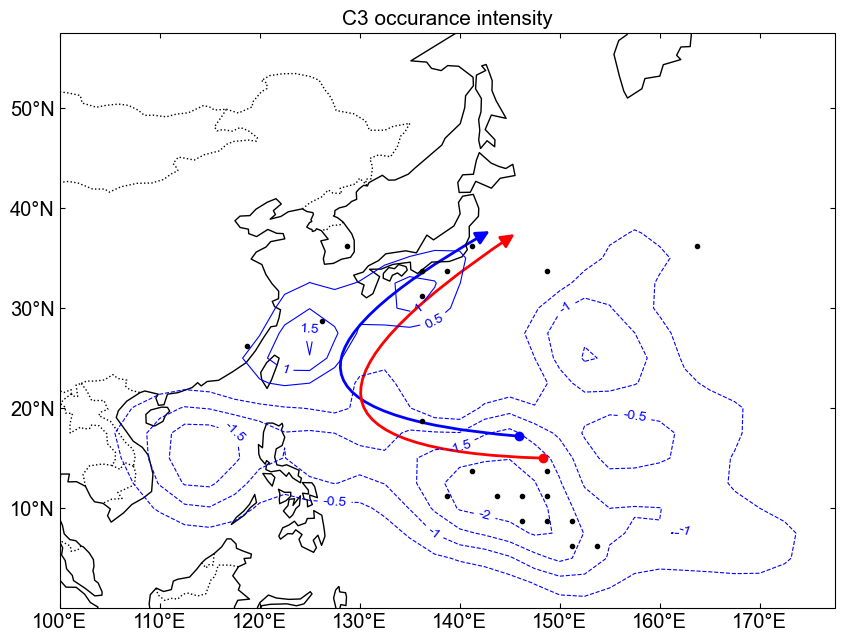

In [8]:
# 3. 绘制等值线图
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(100, 181, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(10, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(100, 181, 10),fontsize = 'x-large') # 设置刻度标签
ax.set_yticklabels(np.arange(10, 61, 10),fontsize = 'x-large') # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# 添加海岸线和国家边界
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')

p3=p2-p1
# 使用高斯滤波对数据进行平滑处理
frequency_grid_smooth = gaussian_filter(p3, sigma=1)
# 绘制平滑后的等值线图
contour = ax.contour(lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth, 
                     transform=ccrs.PlateCarree(), colors='b', linewidths=0.8, 
                     levels=np.arange(-4.5, 4.5, 0.5))


# 遍历等值线，移除level == 0的线
for i, collection in enumerate(contour.collections):
    if contour.levels[i] == 0:
        collection.remove()
        
# ax.clabel(contour, inline=True)        
        
# Use a custom formatter to avoid labeling the contour at level 0
def custom_label_format(val):
    if val == 0:
        return ''  # Do not show label for level 0
    else:
        return f'{val:g}'  # Show other labels normally

# Apply the custom formatter in ax.clabel
ax.clabel(contour, inline=True, fmt=custom_label_format)

        
ax.set_title('C3 occurance intensity', fontsize=15)
start_point = (145.9,17.2)  # 起点
end_point = (143,37.7)  # 终点
control_point = (111.9, 20)  # 控制点，使曲线弯曲
ax.scatter(145.9,17.2,color='b', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='b', transform=ccrs.PlateCarree())
#箭头线
start_point = (148.3, 15)  # 起点
end_point = (145.5, 37.4)  # 终点
control_point = (113.5, 16)  # 控制点，使曲线弯曲
ax.scatter(148.3, 15,color='r', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='red', transform=ccrs.PlateCarree())

# significance_contour = ax.contourf(lon_bins[:-1], lat_bins[:-1], significance_mask, 
#                                    transform=ccrs.PlateCarree(), cmap=mcolors.ListedColormap(['none', 'yellow']), 
#                                    levels=[0, 0.5, 1], alpha=0.4)
# 绘制显著性区域
# significance_level = 0.05  # 设置显著性阈值
# significance_mask = p_values < significance_level  # 获取显著性区域

# # 在现有的图上添加显著性区域
# ax.contourf(lon_bins[:-1], lat_bins[:-1], significance_mask, 
#             transform=ccrs.PlateCarree(), cmap='Reds', alpha=0.4)  # 使用半透明的红色来表示显著区域


plt.scatter(lon_centers1[sig_y], lat_centers1[sig_x], color='black', marker='.', label="p < 0.05")
plt.show()
frequency_grid_smooth2_1=frequency_grid_smooth
sig_y1=sig_y
sig_x1=sig_x

# end

In [9]:
#总的
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
years = np.arange(1982, 1999)
typhoon_numbers = {}

for year in years:
    filtered_data = df[df['year'] == year]['Typhoon ID']
    typhoon_numbers[year] = filtered_data.values.flatten()
            
all_typhoon_ids = [id_num for ids in typhoon_numbers.values() for id_num in ids]
indall = np.array(all_typhoon_ids)

lons = infile['usa_lon'][indall].values
lats = infile['usa_lat'][indall].values

endlon=[]
endlat=[]
for i in range(lons.shape[0]):
    valid_lons = lons[i][~np.isnan(lons[i])][-1]
    valid_lats = lats[i][~np.isnan(lats[i])][-1]
    endlon.append(valid_lons)
    endlat.append(valid_lats)
    
    
    
lon_bins = np.arange(100, 180 + 2.5, 2.5)  # 经度范围从100°E到180°E
lat_bins = np.arange(0, 60 + 2.5, 2.5)     # 纬度范围从0°N到60°N

# 3. 创建一个二维数组，用于存储每个网格的台风路径点出现次数
frequency_grid = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# 4. 遍历每个台风路径，处理有效路径点
for i in range(len(endlon)):  # 遍历每个台风
   
        lon = endlon[i]
        lat = endlat[i]
        
        # 跳过无效路径点 (NaN)
        if np.isnan(lon) or np.isnan(lat):
            continue
        
        # 将有效路径点映射到最近的网格
        lon_idx = np.digitize(lon, lon_bins) - 1  # 经度对应的网格索引
        lat_idx = np.digitize(lat, lat_bins) - 1  # 纬度对应的网格索引
        
        # 统计每个网格中的路径点次数
        if 0 <= lon_idx < frequency_grid.shape[1] and 0 <= lat_idx < frequency_grid.shape[0]:
            frequency_grid[lat_idx, lon_idx] += 1


end1=frequency_grid/17

In [10]:
#总的
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
years = np.arange(1999, 2024)
typhoon_numbers = {}

for year in years:
    filtered_data = df[df['year'] == year]['Typhoon ID']
    typhoon_numbers[year] = filtered_data.values.flatten()
            
all_typhoon_ids = [id_num for ids in typhoon_numbers.values() for id_num in ids]
indall = np.array(all_typhoon_ids)

lons = infile['usa_lon'][indall].values
lats = infile['usa_lat'][indall].values

endlon=[]
endlat=[]
for i in range(lons.shape[0]):
    valid_lons = lons[i][~np.isnan(lons[i])][-1]
    valid_lats = lats[i][~np.isnan(lats[i])][-1]
    endlon.append(valid_lons)
    endlat.append(valid_lats)
    
    
    
lon_bins = np.arange(100, 180 + 2.5, 2.5)  # 经度范围从100°E到180°E
lat_bins = np.arange(0, 60 + 2.5, 2.5)     # 纬度范围从0°N到60°N

# 3. 创建一个二维数组，用于存储每个网格的台风路径点出现次数
frequency_grid = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# 4. 遍历每个台风路径，处理有效路径点
for i in range(len(endlon)):  # 遍历每个台风
   
        lon = endlon[i]
        lat = endlat[i]
        
        # 跳过无效路径点 (NaN)
        if np.isnan(lon) or np.isnan(lat):
            continue
        
        # 将有效路径点映射到最近的网格
        lon_idx = np.digitize(lon, lon_bins) - 1  # 经度对应的网格索引
        lat_idx = np.digitize(lat, lat_bins) - 1  # 纬度对应的网格索引
        
        # 统计每个网格中的路径点次数
        if 0 <= lon_idx < frequency_grid.shape[1] and 0 <= lat_idx < frequency_grid.shape[0]:
            frequency_grid[lat_idx, lon_idx] += 1

end2=frequency_grid/25

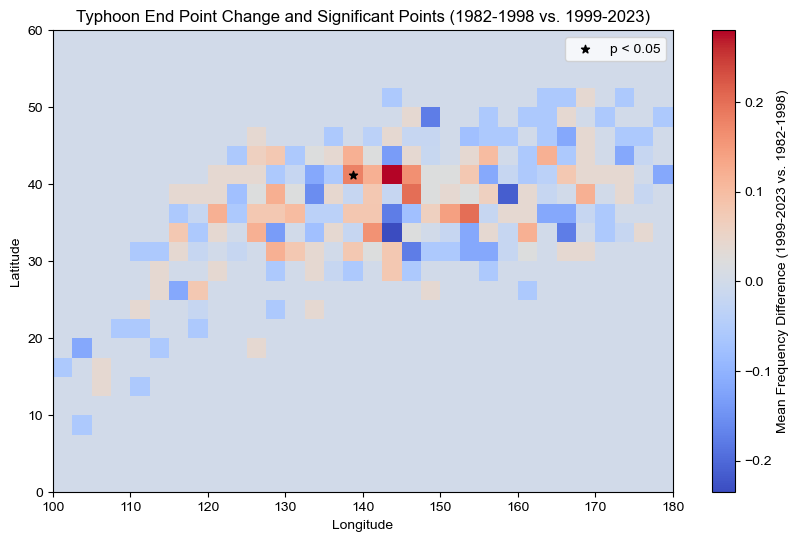

In [11]:
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# 假设 `years` 是从 1982 到 2023 的年份
years = np.arange(1982, 2024)

# 假设 `lat_bins` 和 `lon_bins` 已经定义
lon_bins = np.arange(100, 180 + 2.5, 2.5)  # 经度范围从100°E到180°E
lat_bins = np.arange(0, 60 + 2.5, 2.5)     # 纬度范围从0°N到60°N

# 初始化一个三维数组，用于存储每一年的台风结束点频率
all_years_end_frequency_grid = np.zeros((len(years), len(lat_bins) - 1, len(lon_bins) - 1))

# 1. 计算每一年每个格点的台风结束点频率
for year_idx, year in enumerate(years):
    # 筛选对应年份的数据
    filtered_data = df[df['year'] == year]['Typhoon ID']
    indall = filtered_data.values.flatten()
    
    lons = infile['usa_lon'][indall].values
    lats = infile['usa_lat'][indall].values
    
    # 创建一个二维数组用于存储该年份的台风结束点次数
    end_frequency_grid = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))
    
    # 遍历每个台风的路径点，提取结束点
    for i in range(lons.shape[0]):  # 遍历每个台风
        # 提取每个台风的最后一个有效路径点 (结束点)
        lon = lons[i][~np.isnan(lons[i])][-1]
        lat = lats[i][~np.isnan(lats[i])][-1]
        
        # 跳过无效路径点 (NaN)
#         if np.isnan(lon) or np.isnan(lat):
#             continue
        
        # 将有效路径点映射到最近的网格
        lon_idx = np.digitize(lon, lon_bins) - 1
        lat_idx = np.digitize(lat, lat_bins) - 1
        
        # 统计每个网格中的结束点次数
        if 0 <= lon_idx < end_frequency_grid.shape[1] and 0 <= lat_idx < end_frequency_grid.shape[0]:
            end_frequency_grid[lat_idx, lon_idx] += 1
    
    # 将每年的台风结束点频率存入 `all_years_end_frequency_grid` 的对应年份索引
    all_years_end_frequency_grid[year_idx] = end_frequency_grid

# 2. 将1982-1998年和1999-2023年的结束点频率数据分开
years_1 = np.arange(1982, 1999)  # 1982-1998
years_2 = np.arange(1999, 2024)  # 1999-2023

# 分开两个时期的频率数据
end_freq_grid_1 = all_years_end_frequency_grid[:len(years_1)]
end_freq_grid_2 = all_years_end_frequency_grid[len(years_1):]

# 初始化一个二维数组来存储p值和t统计量
p_values = np.ones((len(lat_bins) - 1, len(lon_bins) - 1))
t_stats = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# 对每个格点执行t检验
for i in range(len(lat_bins) - 1):
    for j in range(len(lon_bins) - 1):
        # 获取两个时期在当前格点的结束点频率值
        data_1 = end_freq_grid_1[:, i, j]
        data_2 = end_freq_grid_2[:, i, j]
        
        # 检查是否有非零的数据点
        if np.sum(data_1) > 0 and np.sum(data_2) > 0:
            # 执行t检验
            t_stat, p_val = ttest_ind(data_1, data_2, equal_var=False)  # 采用不假设方差相等的检验
            
            # 存储t统计量和p值
            t_stats[i, j] = t_stat
            p_values[i, j] = p_val

# 3. 绘制结果，显著性差异点使用星号标记
plt.figure(figsize=(10, 6))
plt.pcolormesh(lon_bins, lat_bins, np.mean(end_freq_grid_2, axis=0) - np.mean(end_freq_grid_1, axis=0), cmap='coolwarm')
plt.colorbar(label="Mean Frequency Difference (1999-2023 vs. 1982-1998)")
plt.title("Typhoon End Point Change and Significant Points (1982-1998 vs. 1999-2023)")

# 设置显著性水平（例如 0.05）
significant_level = 0.1

# 标记显著差异的点
sig_x, sig_y = np.where(p_values < significant_level)

# 计算格点的中心坐标
lon_centers2 = (lon_bins[:-1] + lon_bins[1:]) / 2
lat_centers2 = (lat_bins[:-1] + lat_bins[1:]) / 2

# 将sig_x, sig_y转换为经纬度坐标
plt.scatter(lon_centers2[sig_y], lat_centers2[sig_x], color='black', marker='*', label="p < 0.05")

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()


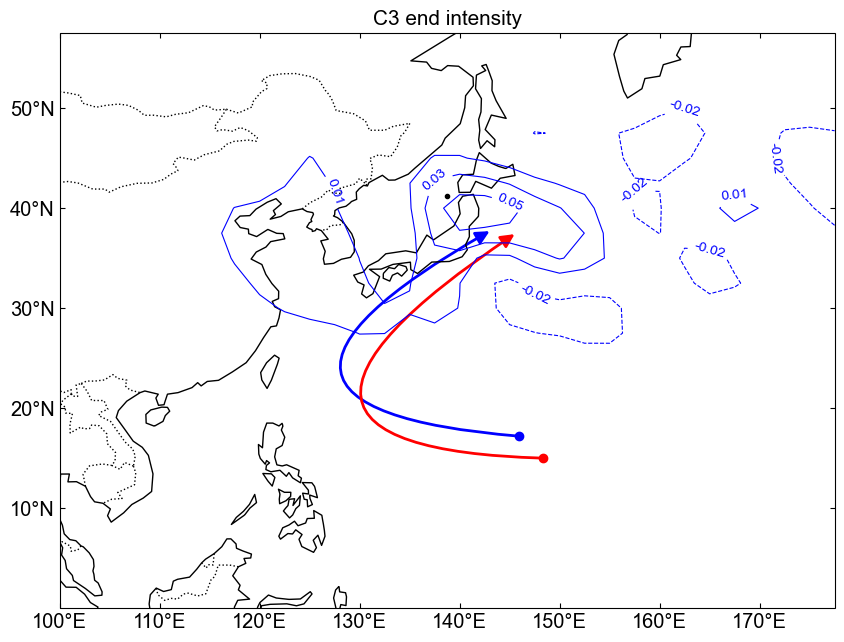

In [12]:

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(100, 181, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(10, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(100, 181, 10),fontsize = 'x-large') # 设置刻度标签
ax.set_yticklabels(np.arange(10, 61, 10),fontsize = 'x-large') # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# 添加海岸线和国家边界
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')


end3=end2-end1

# 使用高斯滤波对数据进行平滑处理
frequency_grid_smooth = gaussian_filter(end3, sigma=1.2)

# 绘制平滑后的等值线图
contour = ax.contour(lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth , 
                     transform=ccrs.PlateCarree(), colors='b', linewidths=0.8, 
                     levels=np.concatenate((np.arange(-0.5, 0, 0.02), np.arange(0.01, 0.5, 0.02))))  # 不包含0
ax.clabel(contour, fmt='%.2f',inline=True)
start_point = (145.9,17.2)  # 起点
end_point = (143,37.7)  # 终点
control_point = (111.9, 20)  # 控制点，使曲线弯曲
ax.scatter(145.9,17.2,color='b', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='b', transform=ccrs.PlateCarree())
#箭头线
start_point = (148.3, 15)  # 起点
end_point = (145.5, 37.4)  # 终点
control_point = (113.5, 16)  # 控制点，使曲线弯曲
ax.scatter(148.3, 15,color='r', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='red', transform=ccrs.PlateCarree())
plt.scatter(lon_centers2[sig_y], lat_centers2[sig_x], color='black', marker='.')
ax.set_title('C3 end intensity', fontsize=15)
plt.show()
frequency_grid_smooth_end=frequency_grid_smooth
sig_y2=sig_y
sig_x2=sig_x

# genesis

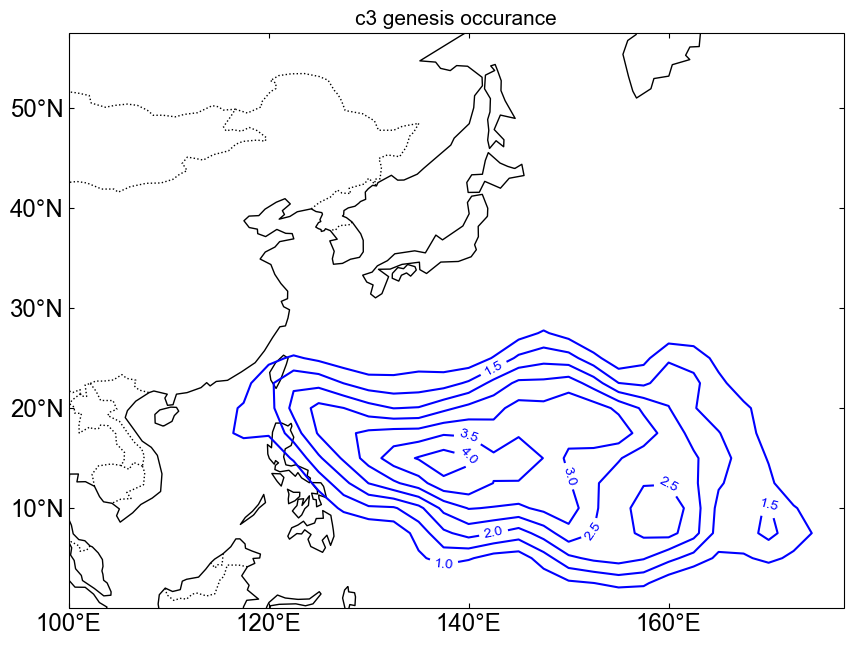

In [13]:
#总的
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
years = np.arange(1982, 2024)
typhoon_numbers = {}

for year in years:
    filtered_data = df[df['year'] == year]['Typhoon ID']
    typhoon_numbers[year] = filtered_data.values.flatten()
            
all_typhoon_ids = [id_num for ids in typhoon_numbers.values() for id_num in ids]
indall = np.array(all_typhoon_ids)

lons = infile['usa_lon'][indall].values
lats = infile['usa_lat'][indall].values

endlon=[]
endlat=[]
for i in range(lons.shape[0]):
    valid_lons = lons[i][~np.isnan(lons[i])][0]
    valid_lats = lats[i][~np.isnan(lats[i])][0]
    endlon.append(valid_lons)
    endlat.append(valid_lats)
    
    
    
lon_bins = np.arange(100, 180 + 2.5, 2.5)  # 经度范围从100°E到180°E
lat_bins = np.arange(0, 60 + 2.5, 2.5)     # 纬度范围从0°N到60°N

# 3. 创建一个二维数组，用于存储每个网格的台风路径点出现次数
frequency_grid = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# 4. 遍历每个台风路径，处理有效路径点
for i in range(len(endlon)):  # 遍历每个台风
   
        lon = endlon[i]
        lat = endlat[i]
        
        # 跳过无效路径点 (NaN)
        if np.isnan(lon) or np.isnan(lat):
            continue
        
        # 将有效路径点映射到最近的网格
        lon_idx = np.digitize(lon, lon_bins) - 1  # 经度对应的网格索引
        lat_idx = np.digitize(lat, lat_bins) - 1  # 纬度对应的网格索引
        
        # 统计每个网格中的路径点次数
        if 0 <= lon_idx < frequency_grid.shape[1] and 0 <= lat_idx < frequency_grid.shape[0]:
            frequency_grid[lat_idx, lon_idx] += 1



# # 2. 创建 lon 和 lat 网格，用于绘图
lon_grid, lat_grid = np.meshgrid(lon_bins[:-1], lat_bins[:-1])  # 忽略最后一个边界，因为它用于网格的间隔

# # 3. 绘制等值线图
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(100, 181, 20), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(10, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(100, 181, 20),fontsize = 'xx-large') # 设置刻度标签
ax.set_yticklabels(np.arange(10, 61, 10),fontsize = 'xx-large') # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# 添加海岸线和国家边界
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')

# 绘制等值线图，使用生成的 lon_grid 和 lat_grid
# contour = ax.contour(lon_grid, lat_grid, frequency_grid / 42, transform=ccrs.PlateCarree(), colors='b',linewidths=0.8, levels=np.arange(1, np.max(frequency_grid / 42)+1, 1))
# ax.clabel(contour,inline='True')




# 使用高斯滤波对数据进行平滑处理
frequency_grid_smooth = gaussian_filter(frequency_grid, sigma=0.9)

# 绘制平滑后的等值线图
contour = ax.contour(lon_grid, lat_grid, frequency_grid_smooth, 
                     transform=ccrs.PlateCarree(),colors='blue', linewidths=1.5, 
                     levels=np.arange(1, np.max(frequency_grid_smooth ) + 1, 0.5))
ax.clabel(contour, inline=True)





ax.set_title('c3 genesis occurance', fontsize=15)

plt.show()

In [14]:
#总的
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
years = np.arange(1982, 1999)
typhoon_numbers = {}

for year in years:
    filtered_data = df[df['year'] == year]['Typhoon ID']
    typhoon_numbers[year] = filtered_data.values.flatten()
            
all_typhoon_ids = [id_num for ids in typhoon_numbers.values() for id_num in ids]
indall = np.array(all_typhoon_ids)

lons = infile['usa_lon'][indall].values
lats = infile['usa_lat'][indall].values

endlon=[]
endlat=[]
for i in range(lons.shape[0]):
    valid_lons = lons[i][~np.isnan(lons[i])][0]
    valid_lats = lats[i][~np.isnan(lats[i])][0]
    endlon.append(valid_lons)
    endlat.append(valid_lats)
    
    
    
lon_bins = np.arange(100, 180 + 2.5, 2.5)  # 经度范围从100°E到180°E
lat_bins = np.arange(0, 60 + 2.5, 2.5)     # 纬度范围从0°N到60°N

# 3. 创建一个二维数组，用于存储每个网格的台风路径点出现次数
frequency_grid = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# 4. 遍历每个台风路径，处理有效路径点
for i in range(len(endlon)):  # 遍历每个台风
   
        lon = endlon[i]
        lat = endlat[i]
        
        # 跳过无效路径点 (NaN)
        if np.isnan(lon) or np.isnan(lat):
            continue
        
        # 将有效路径点映射到最近的网格
        lon_idx = np.digitize(lon, lon_bins) - 1  # 经度对应的网格索引
        lat_idx = np.digitize(lat, lat_bins) - 1  # 纬度对应的网格索引
        
        # 统计每个网格中的路径点次数
        if 0 <= lon_idx < frequency_grid.shape[1] and 0 <= lat_idx < frequency_grid.shape[0]:
            frequency_grid[lat_idx, lon_idx] += 1


end1=frequency_grid/17

In [15]:
#总的
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
years = np.arange(1999, 2024)
typhoon_numbers = {}

for year in years:
    filtered_data = df[df['year'] == year]['Typhoon ID']
    typhoon_numbers[year] = filtered_data.values.flatten()
            
all_typhoon_ids = [id_num for ids in typhoon_numbers.values() for id_num in ids]
indall = np.array(all_typhoon_ids)

lons = infile['usa_lon'][indall].values
lats = infile['usa_lat'][indall].values

endlon=[]
endlat=[]
for i in range(lons.shape[0]):
    valid_lons = lons[i][~np.isnan(lons[i])][0]
    valid_lats = lats[i][~np.isnan(lats[i])][0]
    endlon.append(valid_lons)
    endlat.append(valid_lats)
    
    
    
lon_bins = np.arange(100, 180 + 2.5, 2.5)  # 经度范围从100°E到180°E
lat_bins = np.arange(0, 60 + 2.5, 2.5)     # 纬度范围从0°N到60°N

# 3. 创建一个二维数组，用于存储每个网格的台风路径点出现次数
frequency_grid = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# 4. 遍历每个台风路径，处理有效路径点
for i in range(len(endlon)):  # 遍历每个台风
   
        lon = endlon[i]
        lat = endlat[i]
        
        # 跳过无效路径点 (NaN)
        if np.isnan(lon) or np.isnan(lat):
            continue
        
        # 将有效路径点映射到最近的网格
        lon_idx = np.digitize(lon, lon_bins) - 1  # 经度对应的网格索引
        lat_idx = np.digitize(lat, lat_bins) - 1  # 纬度对应的网格索引
        
        # 统计每个网格中的路径点次数
        if 0 <= lon_idx < frequency_grid.shape[1] and 0 <= lat_idx < frequency_grid.shape[0]:
            frequency_grid[lat_idx, lon_idx] += 1

end2=frequency_grid/25

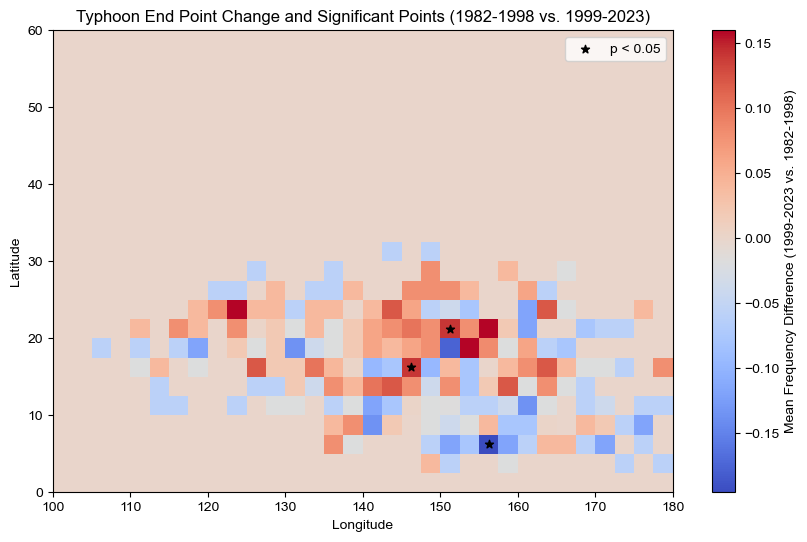

In [16]:
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# 假设 `years` 是从 1982 到 2023 的年份
years = np.arange(1982, 2024)

# 假设 `lat_bins` 和 `lon_bins` 已经定义
lon_bins = np.arange(100, 180 + 2.5, 2.5)  # 经度范围从100°E到180°E
lat_bins = np.arange(0, 60 + 2.5, 2.5)     # 纬度范围从0°N到60°N

# 初始化一个三维数组，用于存储每一年的台风结束点频率
all_years_end_frequency_grid = np.zeros((len(years), len(lat_bins) - 1, len(lon_bins) - 1))

# 1. 计算每一年每个格点的台风结束点频率
for year_idx, year in enumerate(years):
    # 筛选对应年份的数据
    filtered_data = df[df['year'] == year]['Typhoon ID']
    indall = filtered_data.values.flatten()
    
    lons = infile['usa_lon'][indall].values
    lats = infile['usa_lat'][indall].values
    
    # 创建一个二维数组用于存储该年份的台风结束点次数
    end_frequency_grid = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))
    
    # 遍历每个台风的路径点，提取结束点
    for i in range(lons.shape[0]):  # 遍历每个台风
        # 提取每个台风的最后一个有效路径点 (结束点)
        lon = lons[i][~np.isnan(lons[i])][0]
        lat = lats[i][~np.isnan(lats[i])][0]
        
        # 跳过无效路径点 (NaN)
#         if np.isnan(lon) or np.isnan(lat):
#             continue
        
        # 将有效路径点映射到最近的网格
        lon_idx = np.digitize(lon, lon_bins) - 1
        lat_idx = np.digitize(lat, lat_bins) - 1
        
        # 统计每个网格中的结束点次数
        if 0 <= lon_idx < end_frequency_grid.shape[1] and 0 <= lat_idx < end_frequency_grid.shape[0]:
            end_frequency_grid[lat_idx, lon_idx] += 1
    
    # 将每年的台风结束点频率存入 `all_years_end_frequency_grid` 的对应年份索引
    all_years_end_frequency_grid[year_idx] = end_frequency_grid

# 2. 将1982-1998年和1999-2023年的结束点频率数据分开
years_1 = np.arange(1982, 1999)  # 1982-1998
years_2 = np.arange(1999, 2024)  # 1999-2023

# 分开两个时期的频率数据
end_freq_grid_1 = all_years_end_frequency_grid[:len(years_1)]
end_freq_grid_2 = all_years_end_frequency_grid[len(years_1):]

# 初始化一个二维数组来存储p值和t统计量
p_values = np.ones((len(lat_bins) - 1, len(lon_bins) - 1))
t_stats = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# 对每个格点执行t检验
for i in range(len(lat_bins) - 1):
    for j in range(len(lon_bins) - 1):
        # 获取两个时期在当前格点的结束点频率值
        data_1 = end_freq_grid_1[:, i, j]
        data_2 = end_freq_grid_2[:, i, j]
        
        # 检查是否有非零的数据点
        if np.sum(data_1) > 0 and np.sum(data_2) > 0:
            # 执行t检验
            t_stat, p_val = ttest_ind(data_1, data_2, equal_var=False)  # 采用不假设方差相等的检验
            
            # 存储t统计量和p值
            t_stats[i, j] = t_stat
            p_values[i, j] = p_val

# 3. 绘制结果，显著性差异点使用星号标记
plt.figure(figsize=(10, 6))
plt.pcolormesh(lon_bins, lat_bins, np.mean(end_freq_grid_2, axis=0) - np.mean(end_freq_grid_1, axis=0), cmap='coolwarm')
plt.colorbar(label="Mean Frequency Difference (1999-2023 vs. 1982-1998)")
plt.title("Typhoon End Point Change and Significant Points (1982-1998 vs. 1999-2023)")

# 设置显著性水平（例如 0.05）
significant_level = 0.2

# 标记显著差异的点
sig_x, sig_y = np.where(p_values < significant_level)

# 计算格点的中心坐标
lon_centers3 = (lon_bins[:-1] + lon_bins[1:]) / 2
lat_centers3 = (lat_bins[:-1] + lat_bins[1:]) / 2

# 将sig_x, sig_y转换为经纬度坐标
plt.scatter(lon_centers3[sig_y], lat_centers3[sig_x], color='black', marker='*', label="p < 0.05")

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()


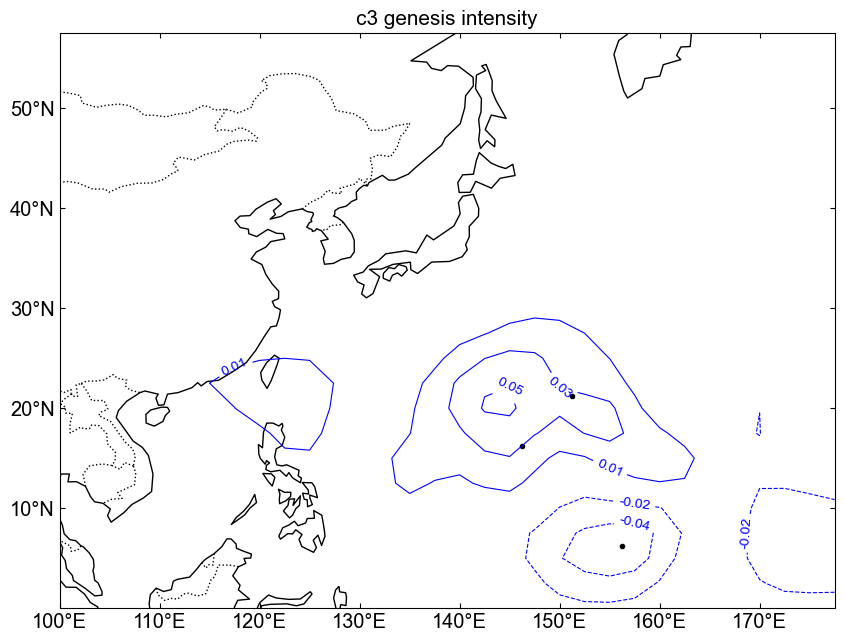

In [17]:

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(100, 181, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(10, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(100, 181, 10),fontsize = 'x-large') # 设置刻度标签
ax.set_yticklabels(np.arange(10, 61, 10),fontsize = 'x-large') # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# 添加海岸线和国家边界
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')


end3=end2-end1

# 使用高斯滤波对数据进行平滑处理
frequency_grid_smooth = gaussian_filter(end3, sigma=1.2)

# 绘制平滑后的等值线图
contour = ax.contour(lon_bins[:-1], lat_bins[:-1],  frequency_grid_smooth , 
                     transform=ccrs.PlateCarree(), colors='b', linewidths=0.8, 
                     levels=np.concatenate((np.arange(-0.2, 0, 0.02), np.arange(0.01, 0.2, 0.02))))  # 不包含0
plt.scatter(lon_centers3[sig_y], lat_centers3[sig_x], color='black', marker='.', label="p < 0.05")
ax.clabel(contour, fmt='%.2f',inline=True)

ax.set_title('c3 genesis intensity', fontsize=15)
plt.show()
sig_y3=sig_y
sig_x3=sig_x

# 组图

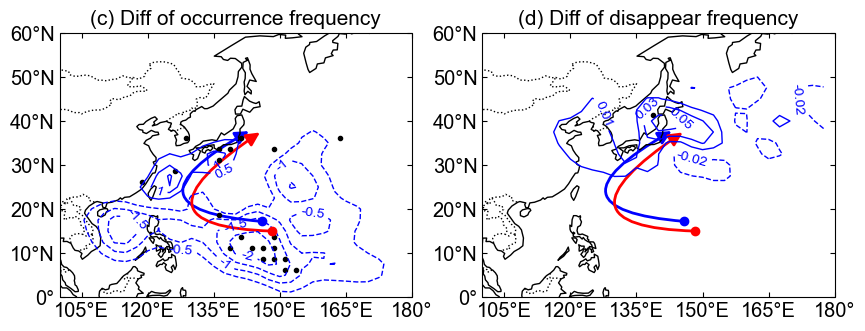

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(10,8))
# ax1=plt.subplot(2,2,1,projection=ccrs.PlateCarree())
# ax=ax1
# ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())
# ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True, direction='in')
# ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
# ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticklabels(np.arange(105, 181, 15), fontsize='x-large')
# ax.set_yticklabels(np.arange(0, 61, 10), fontsize='x-large')
# ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
# ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# ax.coastlines()
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# contour = ax.contour(lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth1, 
#                      transform=ccrs.PlateCarree(), colors='b', linewidths=1, 
#                      levels=np.arange(-4.5, 11, 0.5))
# for i, collection in enumerate(contour.collections):
#     if contour.levels[i] == 0:
#         collection.remove()
# ax.clabel(contour, inline=True, fmt=custom_label_format)
# start_point = (148.3, 15)  # 起点
# end_point = (145.5, 37.4)  # 终点
# control_point = (113.5, 16)  # 控制点，使曲线弯曲
# ax.scatter(148.3, 15,color='r', zorder=5, transform=ccrs.Geodetic())
# draw_bezier_arrow(ax, start_point, control_point, end_point, color='red', transform=ccrs.PlateCarree())
# # 设置标题
# ax.set_title('(a) TC occurrence frequency (P1)', fontsize=15,loc='center')


# ax2=plt.subplot(2,2,2,projection=ccrs.PlateCarree())
# ax=ax2
# ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())
# ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
# ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
# ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
# # ax.set_xticks([0,20,40,60]) # 设置刻度
# ax.set_xticklabels(np.arange(105, 181, 15),fontsize = 'x-large') # 设置刻度标签
# ax.set_yticklabels(np.arange(0, 61, 10),fontsize = 'x-large') # 设置刻度标签
# ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
# ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# # 添加海岸线和国家边界
# ax.coastlines()
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# contour = ax.contour(lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth2, 
#                      transform=ccrs.PlateCarree(), colors='b', linewidths=1, 
#                      levels=np.arange(0, 10, 0.5))
# for i, collection in enumerate(contour.collections):
#     if contour.levels[i] == 0:
#         collection.remove()
# def custom_label_format(val):
#     if val == 0:
#         return ''  # Do not show label for level 0
#     else:
#         return f'{val:g}'  # Show other labels normally
# ax.clabel(contour, inline=True, fmt=custom_label_format)        
# ax.set_title('(b) TC occurrence frequency (P2)', fontsize=15,loc='center')
# start_point = (145.9,17.2)  # 起点
# end_point = (143,37.7)  # 终点
# control_point = (111.9, 20)  # 控制点，使曲线弯曲
# ax.scatter(145.9,17.2,color='b', zorder=5, transform=ccrs.Geodetic())
# draw_bezier_arrow(ax, start_point, control_point, end_point, color='b', transform=ccrs.PlateCarree())


ax3=plt.subplot(2,2,3,projection=ccrs.PlateCarree())
ax=ax3
ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(105, 181, 15),fontsize = 'x-large') # 设置刻度标签
ax.set_yticklabels(np.arange(0, 61, 10),fontsize = 'x-large') # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# 添加海岸线和国家边界
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
# 绘制平滑后的等值线图
contour = ax.contour(lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth2_1, 
                     transform=ccrs.PlateCarree(), colors='b', linewidths=1, 
                     levels=np.arange(-4.5, 4.5, 0.5))
# 遍历等值线，移除level == 0的线
for i, collection in enumerate(contour.collections):
    if contour.levels[i] == 0:
        collection.remove()
def custom_label_format(val):
    if val == 0:
        return ''  # Do not show label for level 0
    else:
        return f'{val:g}'  # Show other labels normally
ax.clabel(contour, inline=True, fmt=custom_label_format)        
ax.set_title('(c) Diff of occurrence frequency', fontsize=15,loc='center')
start_point = (145.9,17.2)  # 起点
end_point = (143,37.7)  # 终点
control_point = (111.9, 20)  # 控制点，使曲线弯曲
ax.scatter(145.9,17.2,color='b', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='b', transform=ccrs.PlateCarree())
#箭头线
start_point = (148.3, 15)  # 起点
end_point = (145.5, 37.4)  # 终点
control_point = (113.5, 16)  # 控制点，使曲线弯曲
ax.scatter(148.3, 15,color='r', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='red', transform=ccrs.PlateCarree())
plt.scatter(lon_centers1[sig_y1], lat_centers1[sig_x1], color='black', marker='.', label="p < 0.05")


ax4=plt.subplot(2,2,4,projection=ccrs.PlateCarree())
ax=ax4
ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(105, 181, 15),fontsize = 'x-large') # 设置刻度标签
ax.set_yticklabels(np.arange(0, 61, 10),fontsize = 'x-large') # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# 添加海岸线和国家边界
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
# 绘制平滑后的等值线图
contour = ax.contour(lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth_end , 
                     transform=ccrs.PlateCarree(), colors='b', linewidths=1, 
                     levels=np.concatenate((np.arange(-0.5, 0, 0.02), np.arange(0.01, 0.5, 0.02))))  # 不包含0
ax.clabel(contour, fmt='%.2f',inline=True)
start_point = (145.9,17.2)  # 起点
end_point = (143,37.7)  # 终点
control_point = (111.9, 20)  # 控制点，使曲线弯曲
ax.scatter(145.9,17.2,color='b', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='b', transform=ccrs.PlateCarree())
#箭头线
start_point = (148.3, 15)  # 起点
end_point = (145.5, 37.4)  # 终点
control_point = (113.5, 16)  # 控制点，使曲线弯曲
ax.scatter(148.3, 15,color='r', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='red', transform=ccrs.PlateCarree())
plt.scatter(lon_centers2[sig_y2], lat_centers2[sig_x2], color='black', marker='.')
ax.set_title('(d) Diff of disappear frequency', fontsize=15,loc='center')

plt.show()

1982-1998年平均纬度: 37.40693650218104, 经度: 145.49248575199547
1999-2023年平均纬度: 37.778787918421095, 经度: 143.45497791901295
纬度的t检验统计量: -0.5520973656170441, p值: 0.5812907210918806
经度的t检验统计量: 1.2301546705023911, p值: 0.2195112557916337


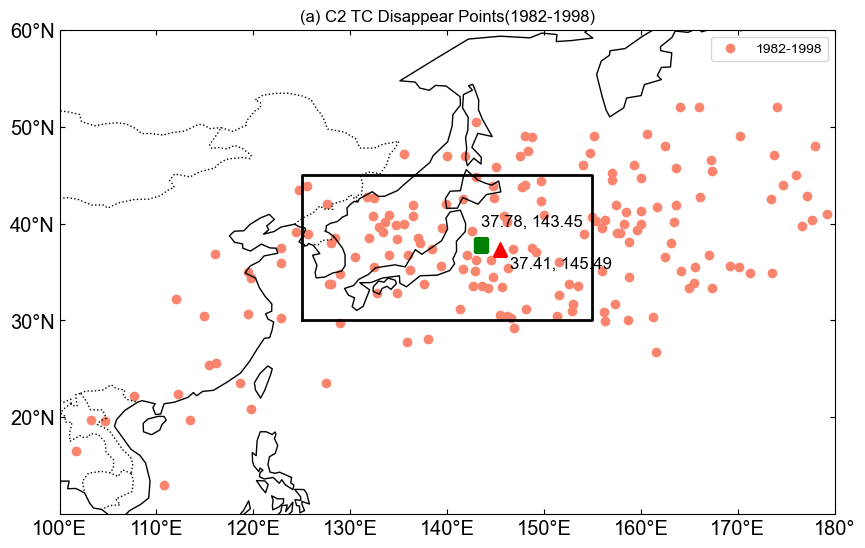

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
import cartopy.mpl.ticker as cticker
# 加载数据
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
id1 = df['Typhoon ID']
idyr = df['year']
oriloclat = df['toendlat']
oriloclon = df['toendlon']

# 分成两个时期的数据
df_period1 = df[(df['year'] >= 1982) & (df['year'] <= 1998)]
df_period2 = df[(df['year'] >= 2000) & (df['year'] <= 2023)]

# 计算两个时期的经纬度平均值
mean_lat_period1 = df_period1['toendlat'].mean()
mean_lon_period1 = df_period1['toendlon'].mean()

mean_lat_period2 = df_period2['toendlat'].mean()
mean_lon_period2 = df_period2['toendlon'].mean()

print(f"1982-1998年平均纬度: {mean_lat_period1}, 经度: {mean_lon_period1}")
print(f"1999-2023年平均纬度: {mean_lat_period2}, 经度: {mean_lon_period2}")

# 执行t检验，检验两个时期的台风起点纬度的显著性差异
t_stat_lat, p_value_lat = stats.ttest_ind(df_period1['toendlat'], df_period2['toendlat'], equal_var=False)
t_stat_lon, p_value_lon = stats.ttest_ind(df_period1['toendlon'], df_period2['toendlon'], equal_var=False)

print(f"纬度的t检验统计量: {t_stat_lat}, p值: {p_value_lat}")
print(f"经度的t检验统计量: {t_stat_lon}, p值: {p_value_lon}")

# 设置地图和特征
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([100, 180, 10, 50])  # 设置地图的经纬度范围
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(100, 181, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(20, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(100, 181, 10),fontsize = 'x-large') # 设置刻度标签
ax.set_yticklabels(np.arange(20, 61, 10),fontsize = 'x-large') # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

# 标记是否已添加图例
added_legend = {'1982-1998': False, '1999-2023': False}

# 绘制台风的起点，根据年份使用不同颜色
for i in range(len(id1)):
    indall = id1[i]
    year = idyr[i]
    lat = oriloclat[i]  # 使用台风起点纬度
    lon = oriloclon[i]  # 使用台风起点经度

    # 选择颜色和标签
    if 1982 <= year <= 1998:
        color = '#fa856f'
        label = '1982-1998'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic())

# 添加图例
ax.legend(loc='upper right')

# 在图中标出两个时期的平均值，并用三角形和正方形表示
# 标出1982-1998年时期的平均值
ax.scatter(mean_lon_period1, mean_lat_period1, color='r', marker='^', s=100, label=f'1982-1998 Avg ({mean_lat_period1:.2f}, {mean_lon_period1:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period1 + 1, mean_lat_period1 - 2, f'{mean_lat_period1:.2f}, {mean_lon_period1:.2f}', fontsize=12, transform=ccrs.Geodetic())

# 标出1999-2023年时期的平均值
ax.scatter(mean_lon_period2, mean_lat_period2, color ='g', marker='s', s=100, label=f'1999-2023 Avg ({mean_lat_period2:.2f}, {mean_lon_period2:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period2 , mean_lat_period2 + 2, f'{mean_lat_period2:.2f}, {mean_lon_period2:.2f}', fontsize=12, transform=ccrs.Geodetic())

extent = [125, 155, 30, 45]
ax.plot([extent[0], extent[1], extent[1], extent[0], extent[0]], 
        [extent[2], extent[2], extent[3], extent[3], extent[2]], 
        color='k', transform=ccrs.PlateCarree(),linewidth=2,)

plt.title('(a) C2 TC Disappear Points(1982-1998)')
plt.show()


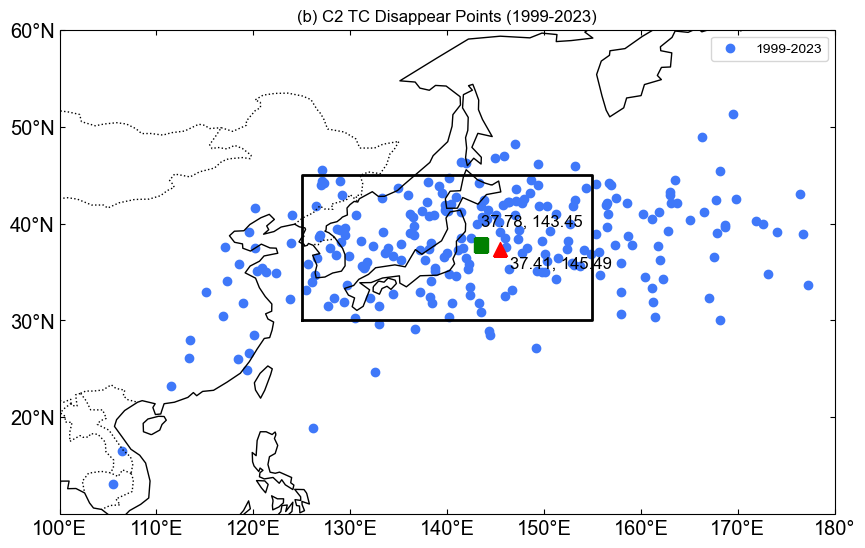

In [20]:
# 设置地图和特征
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([100, 180, 10, 50])  # 设置地图的经纬度范围
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(100, 181, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(20, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(100, 181, 10),fontsize = 'x-large') # 设置刻度标签
ax.set_yticklabels(np.arange(20, 61, 10),fontsize = 'x-large') # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

# 标记是否已添加图例
added_legend = {'1982-1998': False, '1999-2023': False}

# 绘制台风的起点，根据年份使用不同颜色
for i in range(len(id1)):
    indall = id1[i]
    year = idyr[i]
    lat = oriloclat[i]  # 使用台风起点纬度
    lon = oriloclon[i]  # 使用台风起点经度

    if 1999 <= year <= 2023:
        color =  '#3f78f9'
        label = '1999-2023'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic())

# 添加图例
ax.legend(loc='upper right')
# 在图中标出两个时期的平均值，并用三角形和正方形表示

# 标出1982-1998年时期的平均值
ax.scatter(mean_lon_period1, mean_lat_period1, color='r', marker='^', s=100, label=f'1982-1998 Avg ({mean_lat_period1:.2f}, {mean_lon_period1:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period1 + 1, mean_lat_period1-2, f'{mean_lat_period1:.2f}, {mean_lon_period1:.2f}', fontsize=12, transform=ccrs.Geodetic())

# 标出1999-2023年时期的平均值
ax.scatter(mean_lon_period2, mean_lat_period2, color ='g', marker='s', s=100, label=f'1999-2023 Avg ({mean_lat_period2:.2f}, {mean_lon_period2:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period2 , mean_lat_period2+2, f'{mean_lat_period2:.2f}, {mean_lon_period2:.2f}', fontsize=12, transform=ccrs.Geodetic())

extent = [125, 155, 30, 45]
ax.plot([extent[0], extent[1], extent[1], extent[0], extent[0]], 
        [extent[2], extent[2], extent[3], extent[3], extent[2]], 
        color='black', transform=ccrs.PlateCarree(),linewidth=2,)

# extent = [105, 125, 20, 30]
# ax.plot([extent[0], extent[1], extent[1], extent[0], extent[0]], 
#         [extent[2], extent[2], extent[3], extent[3], extent[2]], 
#         color='black', transform=ccrs.PlateCarree(),linewidth=2,)

# extent = [105, 115, 20, 25]
# ax.plot([extent[0], extent[1], extent[1], extent[0], extent[0]], 
#         [extent[2], extent[2], extent[3], extent[3], extent[2]], 
#         color='black', transform=ccrs.PlateCarree(),linewidth=2,)
# 设置标题和显示图形
plt.title('(b) C2 TC Disappear Points (1999-2023)')
plt.show()


In [21]:
color1='r'
color2='b'

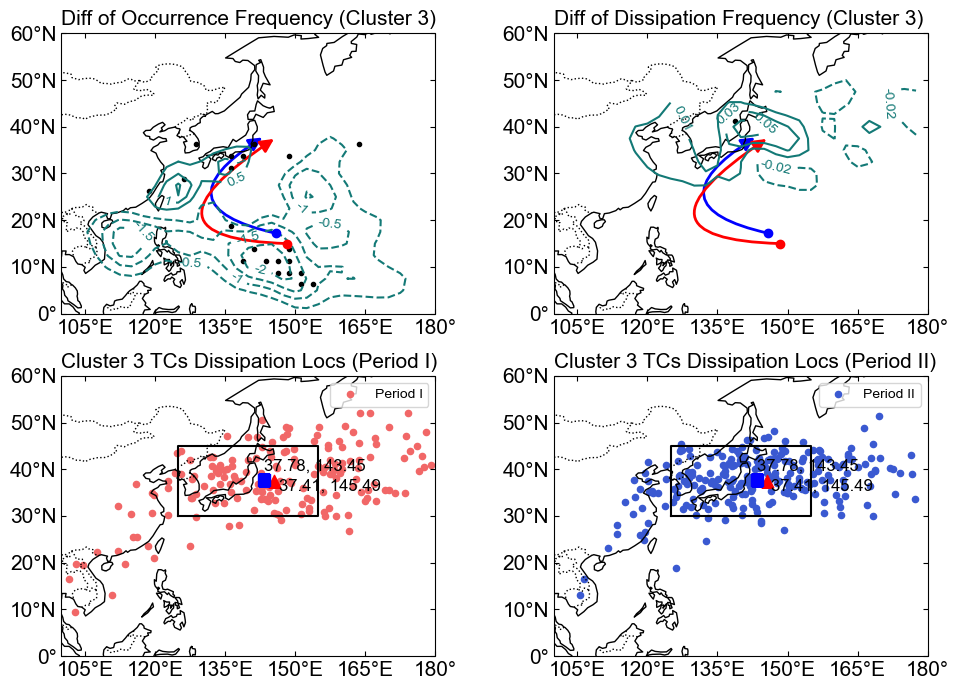

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
color3='#A3255C'
fig=plt.figure(figsize=(10,7))
ax3=plt.subplot(2,2,1,projection=ccrs.PlateCarree())
ax=ax3
# for spine in ax.spines.values():
#     spine.set_linewidth(1.2) 
ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(105, 181, 15),fontsize =15) # 设置刻度标签
ax.set_yticklabels(np.arange(0, 61, 10),fontsize = 15) # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# 添加海岸线和国家边界
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
# 绘制平滑后的等值线图
contour = ax.contour(lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth2_1, 
                     transform=ccrs.PlateCarree(), colors='#137976', linewidths=1.5, 
                     levels=np.arange(-4.5, 4.5, 0.5))

for i, collection in enumerate(contour.collections):
    if contour.levels[i] == 0:
        collection.remove()
def custom_label_format(val):
    if val == 0:
        return ''  # Do not show label for level 0
    else:
        return f'{val:g}'  # Show other labels normally
ax.clabel(contour, inline=True, fmt=custom_label_format)        
ax.set_title('Diff of Occurrence Frequency (Cluster 3)', fontsize=15,loc='left')


#箭头线
start_point = (145.9,17.2)  # 起点
end_point = (143,37.7)  # 终点
control_point = (120, 23)  # 控制点，使曲线弯曲
ax.scatter(145.9,17.2,color='b', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='b', transform=ccrs.PlateCarree())

start_point = (148.3, 15)  # 起点
end_point = (145.5, 37.4)  # 终点
control_point = (113.5, 16)  # 控制点，使曲线弯曲
ax.scatter(148.3, 15,color='r', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='r', transform=ccrs.PlateCarree())
plt.scatter(lon_centers1[sig_y1], lat_centers1[sig_x1], color='black', marker='.', label="p < 0.05")


ax4=plt.subplot(2,2,2,projection=ccrs.PlateCarree())
ax=ax4
# for spine in ax.spines.values():
#     spine.set_linewidth(1.2) 
ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(105, 181, 15),fontsize = 15) # 设置刻度标签
ax.set_yticklabels(np.arange(0, 61, 10),fontsize = 15) # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# 添加海岸线和国家边界
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')

contour = ax.contour(lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth_end , 
                     transform=ccrs.PlateCarree(), colors='#137976', linewidths=1.5, 
                     levels=np.concatenate((np.arange(-0.5, 0, 0.02), np.arange(0.01, 0.5, 0.02))))  # 不包含0
ax.clabel(contour, fmt='%.2f',inline=True)

#箭头线
start_point = (145.9,17.2)  # 起点
end_point = (143,37.7)  # 终点
control_point = (120, 23)  # 控制点，使曲线弯曲
ax.scatter(145.9,17.2,color='b', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='b', transform=ccrs.PlateCarree())

start_point = (148.3, 15)  # 起点
end_point = (145.5, 37.4)  # 终点
control_point = (113.5, 16)  # 控制点，使曲线弯曲
ax.scatter(148.3, 15,color='r', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='r', transform=ccrs.PlateCarree())
plt.scatter(lon_centers2[sig_y2], lat_centers2[sig_x2], color='black', marker='.')
ax.set_title('Diff of Dissipation Frequency (Cluster 3)', fontsize=15,loc='left')


# color1='#F16767'
# color2='#3463aD'
color1='#F16767'
color2='#3A59D1'


ax1=plt.subplot(2,2,3,projection=ccrs.PlateCarree())
ax=ax1
# for spine in ax.spines.values():
#     spine.set_linewidth(1.2) 
ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True, direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15), fontsize=15)
ax.set_yticklabels(np.arange(0, 61, 10), fontsize=15)
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
added_legend = {'Period I': False, 'Period II': False}

# 绘制台风的起点，根据年份使用不同颜色
for i in range(len(id1)):
    indall = id1[i]
    year = idyr[i]
    lat = oriloclat[i]  # 使用台风起点纬度
    lon = oriloclon[i]  # 使用台风起点经度

    # 选择颜色和标签
    if 1982 <= year <= 1998:
        color = color1
        label = 'Period I'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label,s=20)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(),s=20)

# 添加图例
ax.legend(loc='upper right')

# 在图中标出两个时期的平均值，并用三角形和正方形表示
# 标出1982-1998年时期的平均值
ax.scatter(mean_lon_period1, mean_lat_period1, color='r', marker='^', s=80, label=f'1982-1998 Avg ({mean_lat_period1:.2f}, {mean_lon_period1:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period1 + 1, mean_lat_period1 - 2, f'{mean_lat_period1:.2f}, {mean_lon_period1:.2f}', fontsize=12, transform=ccrs.Geodetic())

# 标出1999-2023年时期的平均值
ax.scatter(mean_lon_period2, mean_lat_period2, color ='b', marker='s', s=80, label=f'1999-2023 Avg ({mean_lat_period2:.2f}, {mean_lon_period2:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period2 , mean_lat_period2 + 2, f'{mean_lat_period2:.2f}, {mean_lon_period2:.2f}', fontsize=12, transform=ccrs.Geodetic())

extent = [125, 155, 30, 45]
ax.plot([extent[0], extent[1], extent[1], extent[0], extent[0]], 
        [extent[2], extent[2], extent[3], extent[3], extent[2]], 
        color='k', transform=ccrs.PlateCarree())

ax.set_title('Cluster 3 TCs Dissipation Locs (Period I)', fontsize=15,loc='left')


ax2=plt.subplot(2,2,4,projection=ccrs.PlateCarree())
ax=ax2
# for spine in ax.spines.values():
#     spine.set_linewidth(1.2) 
ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(105, 181, 15),fontsize=15) # 设置刻度标签
ax.set_yticklabels(np.arange(0, 61, 10),fontsize =15) # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# 添加海岸线和国家边界
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
added_legend = {'Period I': False, 'Period II': False}

# 绘制台风的起点，根据年份使用不同颜色
for i in range(len(id1)):
    indall = id1[i]
    year = idyr[i]
    lat = oriloclat[i]  # 使用台风起点纬度
    lon = oriloclon[i]  # 使用台风起点经度

    if 1999 <= year <= 2023:
        color =  color2
        label = 'Period II'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label,s=20)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(),s=20)

# 添加图例
ax.legend(loc='upper right')
# 在图中标出两个时期的平均值，并用三角形和正方形表示

# 标出1982-1998年时期的平均值
ax.scatter(mean_lon_period1, mean_lat_period1, color='r', marker='^', s=80, label=f'1982-1998 Avg ({mean_lat_period1:.2f}, {mean_lon_period1:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period1 + 1, mean_lat_period1-2, f'{mean_lat_period1:.2f}, {mean_lon_period1:.2f}', fontsize=12, transform=ccrs.Geodetic())

# 标出1999-2023年时期的平均值
ax.scatter(mean_lon_period2, mean_lat_period2, color ='b', marker='s', s=80, label=f'1999-2023 Avg ({mean_lat_period2:.2f}, {mean_lon_period2:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period2 , mean_lat_period2+2, f'{mean_lat_period2:.2f}, {mean_lon_period2:.2f}', fontsize=12, transform=ccrs.Geodetic())

extent = [125, 155, 30, 45]
ax.plot([extent[0], extent[1], extent[1], extent[0], extent[0]], 
        [extent[2], extent[2], extent[3], extent[3], extent[2]], 
        color='black', transform=ccrs.PlateCarree())
ax.set_title('Cluster 3 TCs Dissipation Locs (Period II)', fontsize=15,loc='left')

plt.tight_layout()
plt.savefig("03zutu301.pdf",transparent = True)
plt.show()

Text(0.0, 1.0, 'Diff of Occurrence Frequency (Cluster 3)')

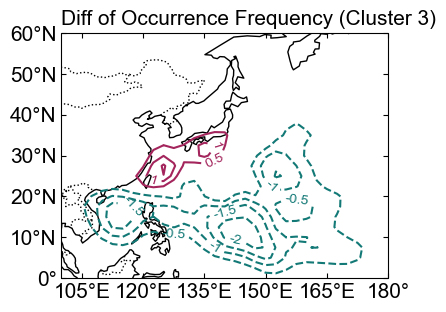

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

# 设置颜色
positive_color = '#A3255C'  # 红色实线
negative_color = '#137976'  # 绿色虚线

# 设置绘图
fig = plt.figure(figsize=(10, 7))
ax = plt.subplot(2, 2, 1, projection=ccrs.PlateCarree())
ax.set_extent([100, 180, 0, 60], crs=ccrs.PlateCarree())
ax.tick_params(left=True, right=True, top=True, bottom=True,
               labelleft=True, labelbottom=True, direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15), fontsize=15)
ax.set_yticklabels(np.arange(0, 61, 10), fontsize=15)
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')

# 画正值等值线（红色实线）
positive_levels = np.arange(0.5, 4.5, 0.5)
contour_pos = ax.contour(
    lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth2_1,
    levels=positive_levels, colors=positive_color, linewidths=1.5,
    linestyles='solid', transform=ccrs.PlateCarree()
)

# 画负值等值线（绿色虚线）
negative_levels = np.arange(-4.5, -0.4, 0.5)
contour_neg = ax.contour(
    lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth2_1,
    levels=negative_levels, colors=negative_color, linewidths=1.5,
    linestyles='dashed', transform=ccrs.PlateCarree()
)

# 添加标签（排除0）
def custom_label_format(val):
    return f'{val:g}'

ax.clabel(contour_pos, inline=True, fmt=custom_label_format)
ax.clabel(contour_neg, inline=True, fmt=custom_label_format)

ax.set_title('Diff of Occurrence Frequency (Cluster 3)', fontsize=15, loc='left')


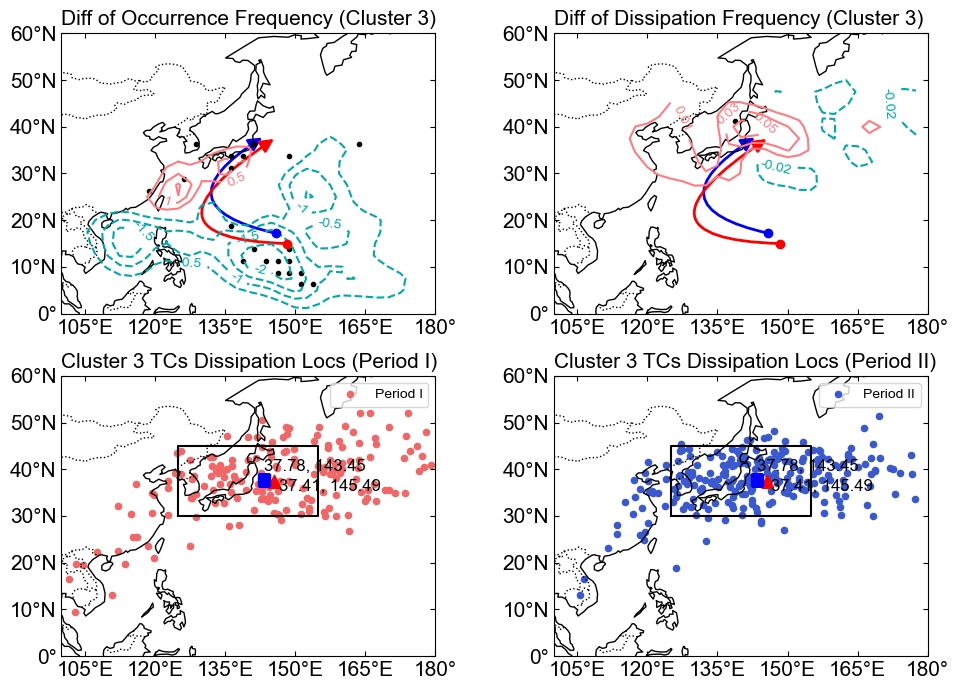

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
color3='#A3255C'
fig=plt.figure(figsize=(10,7))
ax3=plt.subplot(2,2,1,projection=ccrs.PlateCarree())
ax=ax3
# for spine in ax.spines.values():
#     spine.set_linewidth(1.2) 
ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(105, 181, 15),fontsize =15) # 设置刻度标签
ax.set_yticklabels(np.arange(0, 61, 10),fontsize = 15) # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# 添加海岸线和国家边界
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
# # 绘制平滑后的等值线图
# contour = ax.contour(lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth2_1, 
#                      transform=ccrs.PlateCarree(), colors='#137976', linewidths=1.5, 
#                      levels=np.arange(-4.5, 4.5, 0.5))



# 画正值等值线（红色实线）
positive_levels = np.arange(0.5, 4.5, 0.5)
contour_pos = ax.contour(
    lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth2_1,
    levels=positive_levels, colors='#ff7c83', linewidths=1.5,
    linestyles='solid', transform=ccrs.PlateCarree()
)

# 画负值等值线（绿色虚线）
negative_levels = np.arange(-4.5, -0.4, 0.5)
contour_neg = ax.contour(
    lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth2_1,
    levels=negative_levels, colors='#00a7ab', linewidths=1.5,
    linestyles='dashed', transform=ccrs.PlateCarree()
)


for i, collection in enumerate(contour.collections):
    if contour.levels[i] == 0:
        collection.remove()
def custom_label_format(val):
    if val == 0:
        return ''  # Do not show label for level 0
    else:
        return f'{val:g}'  # Show other labels normally
ax.clabel(contour_pos, inline=True, fmt=custom_label_format) 
ax.clabel(contour_neg, inline=True, fmt=custom_label_format)
ax.set_title('Diff of Occurrence Frequency (Cluster 3)', fontsize=15,loc='left')


#箭头线
start_point = (145.9,17.2)  # 起点
end_point = (143,37.7)  # 终点
control_point = (120, 23)  # 控制点，使曲线弯曲
ax.scatter(145.9,17.2,color='b', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='b', transform=ccrs.PlateCarree())

start_point = (148.3, 15)  # 起点
end_point = (145.5, 37.4)  # 终点
control_point = (113.5, 16)  # 控制点，使曲线弯曲
ax.scatter(148.3, 15,color='r', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='r', transform=ccrs.PlateCarree())
plt.scatter(lon_centers1[sig_y1], lat_centers1[sig_x1], color='black', marker='.', label="p < 0.05")


ax4=plt.subplot(2,2,2,projection=ccrs.PlateCarree())
ax=ax4
# for spine in ax.spines.values():
#     spine.set_linewidth(1.2) 
ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(105, 181, 15),fontsize = 15) # 设置刻度标签
ax.set_yticklabels(np.arange(0, 61, 10),fontsize = 15) # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# 添加海岸线和国家边界
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')

# contour = ax.contour(lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth_end , 
#                      transform=ccrs.PlateCarree(), colors='#137976', linewidths=1.5, 
#                      levels=np.concatenate((np.arange(-0.5, 0, 0.02), np.arange(0.01, 0.5, 0.02))))  # 不包含0
# ax.clabel(contour, fmt='%.2f',inline=True)


# 画正值等值线（红色实线）
positive_levels = np.arange(0.01, 0.5, 0.02)
contour_pos = ax.contour(
    lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth_end ,
    levels=positive_levels, colors='#ff7c83', linewidths=1.5,
    linestyles='solid', transform=ccrs.PlateCarree()
)

# 画负值等值线（绿色虚线）
negative_levels = np.arange(-0.5,0, 0.02)
contour_neg = ax.contour(
    lon_bins[:-1], lat_bins[:-1], frequency_grid_smooth_end ,
    levels=negative_levels, colors='#00a7ab', linewidths=1.5,
    linestyles='dashed', transform=ccrs.PlateCarree()
)


# for i, collection in enumerate(contour.collections):
#     if contour.levels[i] == 0:
#         collection.remove()
# def custom_label_format(val):
#     if val == 0:
#         return ''  # Do not show label for level 0
#     else:
#         return f'{val:g}'  # Show other labels normally
ax.clabel(contour_pos, inline=True, fmt=custom_label_format) 
ax.clabel(contour_neg, inline=True, fmt=custom_label_format)


#箭头线
start_point = (145.9,17.2)  # 起点
end_point = (143,37.7)  # 终点
control_point = (120, 23)  # 控制点，使曲线弯曲
ax.scatter(145.9,17.2,color='b', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='b', transform=ccrs.PlateCarree())

start_point = (148.3, 15)  # 起点
end_point = (145.5, 37.4)  # 终点
control_point = (113.5, 16)  # 控制点，使曲线弯曲
ax.scatter(148.3, 15,color='r', zorder=5, transform=ccrs.Geodetic())
draw_bezier_arrow(ax, start_point, control_point, end_point, color='r', transform=ccrs.PlateCarree())
plt.scatter(lon_centers2[sig_y2], lat_centers2[sig_x2], color='black', marker='.')
ax.set_title('Diff of Dissipation Frequency (Cluster 3)', fontsize=15,loc='left')


# color1='#F16767'
# color2='#3463aD'
color1='#F16767'
color2='#3A59D1'


ax1=plt.subplot(2,2,3,projection=ccrs.PlateCarree())
ax=ax1
# for spine in ax.spines.values():
#     spine.set_linewidth(1.2) 
ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True, direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15), fontsize=15)
ax.set_yticklabels(np.arange(0, 61, 10), fontsize=15)
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
added_legend = {'Period I': False, 'Period II': False}

# 绘制台风的起点，根据年份使用不同颜色
for i in range(len(id1)):
    indall = id1[i]
    year = idyr[i]
    lat = oriloclat[i]  # 使用台风起点纬度
    lon = oriloclon[i]  # 使用台风起点经度

    # 选择颜色和标签
    if 1982 <= year <= 1998:
        color = color1
        label = 'Period I'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label,s=20)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(),s=20)

# 添加图例
ax.legend(loc='upper right')

# 在图中标出两个时期的平均值，并用三角形和正方形表示
# 标出1982-1998年时期的平均值
ax.scatter(mean_lon_period1, mean_lat_period1, color='r', marker='^', s=80, label=f'1982-1998 Avg ({mean_lat_period1:.2f}, {mean_lon_period1:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period1 + 1, mean_lat_period1 - 2, f'{mean_lat_period1:.2f}, {mean_lon_period1:.2f}', fontsize=12, transform=ccrs.Geodetic())

# 标出1999-2023年时期的平均值
ax.scatter(mean_lon_period2, mean_lat_period2, color ='b', marker='s', s=80, label=f'1999-2023 Avg ({mean_lat_period2:.2f}, {mean_lon_period2:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period2 , mean_lat_period2 + 2, f'{mean_lat_period2:.2f}, {mean_lon_period2:.2f}', fontsize=12, transform=ccrs.Geodetic())

extent = [125, 155, 30, 45]
ax.plot([extent[0], extent[1], extent[1], extent[0], extent[0]], 
        [extent[2], extent[2], extent[3], extent[3], extent[2]], 
        color='k', transform=ccrs.PlateCarree())

ax.set_title('Cluster 3 TCs Dissipation Locs (Period I)', fontsize=15,loc='left')


ax2=plt.subplot(2,2,4,projection=ccrs.PlateCarree())
ax=ax2
# for spine in ax.spines.values():
#     spine.set_linewidth(1.2) 
ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(105, 181, 15),fontsize=15) # 设置刻度标签
ax.set_yticklabels(np.arange(0, 61, 10),fontsize =15) # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# 添加海岸线和国家边界
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
added_legend = {'Period I': False, 'Period II': False}

# 绘制台风的起点，根据年份使用不同颜色
for i in range(len(id1)):
    indall = id1[i]
    year = idyr[i]
    lat = oriloclat[i]  # 使用台风起点纬度
    lon = oriloclon[i]  # 使用台风起点经度

    if 1999 <= year <= 2023:
        color =  color2
        label = 'Period II'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label,s=20)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(),s=20)

# 添加图例
ax.legend(loc='upper right')
# 在图中标出两个时期的平均值，并用三角形和正方形表示

# 标出1982-1998年时期的平均值
ax.scatter(mean_lon_period1, mean_lat_period1, color='r', marker='^', s=80, label=f'1982-1998 Avg ({mean_lat_period1:.2f}, {mean_lon_period1:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period1 + 1, mean_lat_period1-2, f'{mean_lat_period1:.2f}, {mean_lon_period1:.2f}', fontsize=12, transform=ccrs.Geodetic())

# 标出1999-2023年时期的平均值
ax.scatter(mean_lon_period2, mean_lat_period2, color ='b', marker='s', s=80, label=f'1999-2023 Avg ({mean_lat_period2:.2f}, {mean_lon_period2:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period2 , mean_lat_period2+2, f'{mean_lat_period2:.2f}, {mean_lon_period2:.2f}', fontsize=12, transform=ccrs.Geodetic())

extent = [125, 155, 30, 45]
ax.plot([extent[0], extent[1], extent[1], extent[0], extent[0]], 
        [extent[2], extent[2], extent[3], extent[3], extent[2]], 
        color='black', transform=ccrs.PlateCarree())
ax.set_title('Cluster 3 TCs Dissipation Locs (Period II)', fontsize=15,loc='left')

plt.tight_layout()
plt.savefig("03zutu301.pdf",transparent = True)
plt.show()